In [1]:
import sys
sys.path.append("..")

import jax, os, corner
import jax.numpy as jnp
from jax import grad, config
import matplotlib.pyplot as plt
import numpy as np
config.update("jax_enable_x64", True)
config.update("jax_debug_nans", True)
from functools import partial
from models.priors import Mc_eta_uniform_masses_draw

from models.gw150914_v2 import gwfast_LVGW150914
from models.gwfast.waveforms import TaylorF2_RestrictedPN, IMRPhenomD

from src.pampel import ula_sampler_full_jax_jit
from src.helper import rejection_sampling

from src.helper import plot_cross_section, animate_particles

print(jax.devices())

[cuda(id=0)]


In [2]:
# Initialize model
model = gwfast_LVGW150914(wf_model=IMRPhenomD, nbins=100)

Using ASD from file /home/al44828/projects/sSVN_GW/notebooks/aLIGO_O4_high_asd.txt 
Using ASD from file /home/al44828/projects/sSVN_GW/notebooks/aLIGO_O4_high_asd.txt 
Using ASD from file /home/al44828/projects/sSVN_GW/notebooks/AdV_asd.txt 
fmin:  10.0
fmax:  560.0
df_standard:  5.5
nbins:  100
SNR at true values: 91.57


In [ ]:
# Confirmation that the potential and the gradient are in agreement!
x = model._newDrawFromPrior(1)
test1 = jax.jacobian(model.potential)(x)
test2 = model.gradient_potential(x)
print(test1)
print(test2)

In [ ]:
# Setup and run sampler
n_iter = 100
n_particles = 200

eps = jnp.ones(model.DoF)
eps = eps.at[model.bounded_coordinates].set(1e-6)
eps = eps.at[model.periodic_coordinates].set(1e-6)

# Birth death
stride = n_iter + 1 
rate = 1e-6 
bandwidth = jnp.ones(model.DoF)
bandwidth = bandwidth.at[model.bounded_coordinates].set(0.01)
bandwidth = bandwidth.at[model.periodic_coordinates].set(0.01)

# Initial draw from prior
X0 = model._newDrawFromPrior(n_particles)

key = jax.random.PRNGKey(0)

sam = ula_sampler_full_jax_jit(key, model.potential, model.gradient_potential, n_iter, eps, X0, model.lower_bound, model.upper_bound, stride, rate, bandwidth, model.bounded_coordinates, model.periodic_coordinates)

In [ ]:
# Pick up where you left off
sam = ula_sampler_full_jax_jit(key, model.potential, model.gradient_potential, n_iter, eps * 5, sam[-1], model.lower_bound, model.upper_bound, 100, rate, bandwidth, model.bounded_coordinates, model.periodic_coordinates)

In [ ]:
# Cornerplot results
reshaped_matrix = np.array(sam.reshape((sam.shape[0] * sam.shape[1], 11)))
fig = corner.corner(np.array(model._newDrawFromPrior(50000)), color='r', hist_kwargs={'density':True})
corner.corner(reshaped_matrix[-50000:], hist_kwargs={'density':True}, labels=model.gwfast_param_order, truths=model.true_params, fig=fig)

In [ ]:
# Plot cross sections
from src.helper import plot_cross_section
posterior     = jax.jit(lambda X: jnp.exp(-1 * model.potential(X)))
neg_potential = jax.jit(lambda X: -1 * model.potential(X))
for i in range(model.DoF):
    for j in range(i+1, model.DoF):
        print('Getting cross section for %i, %i' % (i,j))
        plot_cross_section(i, j, neg_potential, 200, model.true_params, model.lower_bound, model.upper_bound, model.gwfast_param_order)

# Check variances

In [ ]:
from src.reparameterization import reparameterized_gradient

X = model._newDrawFromPrior(1000)
gmlpt_X = model.gradient_potential(X)

Y, gmlpt_Y = reparameterized_gradient(X, gmlpt_X, model.lower_bound, model.upper_bound)

vals = gmlpt_Y.at[:, model.periodic_coordinates].set(gmlpt_X[:, model.periodic_coordinates]) 

variances = np.var(np.abs(vals), axis=0)

# Plot the gradient variance
for i in np.argsort(variances)[::-1]:
        plt.hist(vals[:,i], bins=50, label=model.gwfast_param_order[i])
        print(np.max(np.abs(vals[:,i])), i)
plt.title('Gradient variance')
plt.legend()

In [ ]:
plt.bar(model.gwfast_param_order, np.median(np.abs(vals), axis=0))

# Subset experiments

In [7]:
n_particles = 200

# subset_params = jnp.array([0, 1]) # Specific example.
# subset_params = jnp.array([3, 4]) # Specific example.
# subset_params = jnp.array([4, 6]) # Specific example.
subset_params = jnp.array([6, 8]) # Specific example.


X_injection = jnp.tile(model.true_params, n_particles).reshape(n_particles, model.DoF)

def potential_subset(X_red):
    X_ = X_injection.at[:, subset_params].set(X_red)
    return model.potential(X_)

def gradient_subset(X_red):
    X_ = X_injection.at[:, subset_params].set(X_red)
    return model.gradient_potential(X_)[:, subset_params]

# Subset definitions needed for run 
n_iter = 10000

eps = 2e-6

# Birth death
stride = n_iter + 1 
rate = 1e-6 
bandwidth = 0.01
key = jax.random.PRNGKey(42)
X0 = model._newDrawFromPrior(n_particles)

bounded_coordinates_ = []
periodic_coordinates_ = []

if subset_params[0] in model.bounded_coordinates:
    bounded_coordinates_.append(0)
else:
    periodic_coordinates_.append(0)

if subset_params[1] in model.bounded_coordinates:
    bounded_coordinates_.append(1)
else:
    periodic_coordinates_.append(1)

bounded_coordinates_ = jnp.array(bounded_coordinates_)
periodic_coordinates_ = jnp.array(periodic_coordinates_)

sam = ula_sampler_full_jax_jit(key, 
                               potential_subset, 
                               gradient_subset, 
                               n_iter, 
                               eps, 
                               X0[:, subset_params], 
                               model.lower_bound[subset_params], 
                               model.upper_bound[subset_params], 
                               stride, 
                               rate, 
                               bandwidth, 
                               bounded_coordinates_, 
                               periodic_coordinates_)


138024 samples obtained from rejection sampling


In [ ]:
print(model.lower_bound[subset_params])
print(model.upper_bound[subset_params])
print(bounded_coordinates_)
print(periodic_coordinates_)
print(X_injection[0:3, :])

In [8]:
neg_potential = lambda x: -1 * jax.jit(model.potential)(x)

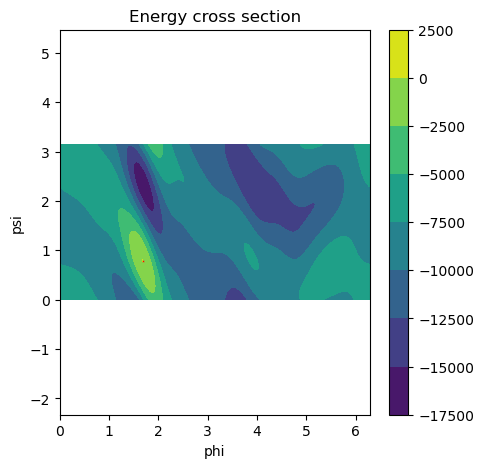

In [9]:
fig, ax = plot_cross_section(subset_params[0], subset_params[1], neg_potential, 200, model.true_params, model.lower_bound, model.upper_bound, model.gwfast_param_order)

In [10]:
animate_particles(sam, 100, fig, ax, save_path='animation_flow2.gif')

MovieWriter imagemagick unavailable; using Pillow instead.


In [ ]:





    #######################################################



    # THIS ONE WORKS ######################################
    # particle_grid = np.zeros((N, d))
    # for i in range(d): # Fix all other parameters
    #     if i == index1:
    #         particle_grid[:, i] = X.flatten()
    #     elif i == index2:
    #         particle_grid[:, i] = Y.flatten()
    #     else:
    #         particle_grid[:, i] = np.ones(N) * injection[i]
    #######################################################